# Federated Algorithm Comparison — Part 2: SCAFFOLD & FedAdam

This notebook runs **SCAFFOLD**  on the MedQuAD dataset (IID split, 3 clients).
Results are saved to `fl_outputs/part2_metrics.json` so that `federated_part3_comparison.ipynb` can load and compare all four algorithms together.

| Algorithm | Key Idea | Extra Cost |
|---|---|---|
| **SCAFFOLD** | Correct client gradients with control variates | 2× communication (sends c_i update) |

**References:**
- SCAFFOLD: Karimireddy et al. (2020) — *SCAFFOLD: Stochastic Controlled Averaging for Federated Learning*



## 1. Install dependencies

In [ ]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets kagglehub trl sentencepiece scikit-learn matplotlib


In [ ]:
import os, copy, random, gc, time, json
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    get_peft_model_state_dict,
    set_peft_model_state_dict,
    prepare_model_for_kbit_training,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 2. Configuration

In [ ]:
@dataclass
class Config:
    # --- model ---
    base_model_id: str = "google/gemma-2b"
    lora_r: int = 3
    lora_alpha: int = 8
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # --- quantization ---
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16
    bnb_4bit_use_double_quant: bool = True

    # --- data ---
    max_seq_len: int = 256
    samples_per_org: int = 300
    val_samples_per_org: int = 30
    num_clients: int = 3

    # --- local training ---
    local_epochs: int = 1
    local_batch_size: int = 2
    grad_accum_steps: int = 4
    lr: float = 2e-4
    max_steps_per_round: int = 60

    # --- federated experiment ---
    total_rounds: int = 3          # rounds to run for EACH algorithm
    fedavg_weighting: str = "uniform"  # "uniform" or "by_dataset_size"

    # --- misc ---
    output_dir: str = "./fl_outputs"
    hf_token: Optional[str] = None

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
CFG


Config(base_model_id='google/gemma-2b', lora_r=3, lora_alpha=8, lora_dropout=0.05, lora_target_modules=('q_proj', 'k_proj', 'v_proj', 'o_proj'), load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True, max_seq_len=256, samples_per_org=300, val_samples_per_org=30, num_clients=3, local_epochs=1, local_batch_size=2, grad_accum_steps=4, lr=0.0002, max_steps_per_round=60, total_rounds=3, fedavg_weighting='uniform', fedadam_server_lr=0.01, fedadam_beta1=0.9, fedadam_beta2=0.99, fedadam_eps=1e-08, output_dir='./fl_outputs', hf_token=None)

## 3. Authentication

Authenticate with HuggingFace (required for gated models like Gemma).


In [ ]:
CFG.hf_token = "hf_xxxxxxx"

from huggingface_hub import login as hf_login
if CFG.hf_token:
    hf_login(token=CFG.hf_token)

import kagglehub
print("Auth ready.")


Auth ready.


## 3b. Download Model (run once — shared by Part 1 & Part 2)

Downloads **Gemma-2B** to a local `./model_cache/` folder using `snapshot_download`.  
**Skip this cell if you have already run it** in either Part 1 or Part 2 — subsequent runs detect the folder and skip automatically.


In [ ]:
from huggingface_hub import snapshot_download

MODEL_CACHE_DIR = "./model_cache"
os.makedirs(MODEL_CACHE_DIR, exist_ok=True)

# Derive a filesystem-safe local directory name from the model ID
local_model_path = os.path.join(MODEL_CACHE_DIR, CFG.base_model_id.replace("/", "--"))

if os.path.isdir(local_model_path) and any(os.scandir(local_model_path)):
    print(f"Model already downloaded at: {local_model_path} — skipping.")
else:
    print(f"Downloading {CFG.base_model_id} → {local_model_path} ...")
    snapshot_download(
        repo_id=CFG.base_model_id,
        local_dir=local_model_path,
        token=CFG.hf_token,
        ignore_patterns=["*.msgpack", "flax_model*", "tf_model*"],  # skip non-PyTorch weights
    )
    print("Download complete.")

print("Model path:", local_model_path)


Model already downloaded at: ./model_cache/google--gemma-2b — skipping.
Model path: ./model_cache/google--gemma-2b


## 3c. Load Model from Local Cache & Apply LoRA


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CFG.load_in_4bit,
    bnb_4bit_quant_type=CFG.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=CFG.bnb_4bit_compute_dtype,
    bnb_4bit_use_double_quant=CFG.bnb_4bit_use_double_quant,
)

# Load tokenizer from local cache (no internet needed after download)
tokenizer = AutoTokenizer.from_pretrained(local_model_path, token=CFG.hf_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load base model from local cache
base_model = AutoModelForCausalLM.from_pretrained(
    local_model_path,
    quantization_config=bnb_config,
    device_map="auto",
    token=CFG.hf_token,
)
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    lora_dropout=CFG.lora_dropout,
    target_modules=list(CFG.lora_target_modules),
    bias="none",
    task_type="CAUSAL_LM",
)
global_model = get_peft_model(base_model, lora_config)
global_model.print_trainable_parameters()

# Save the initial (untrained) LoRA state — we reset to this before each algorithm
initial_lora_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}
print("Initial LoRA state saved. Will reset to this before each algorithm.")


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 691,200 || all params: 2,506,863,616 || trainable%: 0.0276
Initial LoRA state saved. Will reset to this before each algorithm.


## 4. Dataset: Download, Preprocess, and IID Split

In [ ]:
def find_csv(folder, prefer_substrings=None):
    csvs = []
    for root, _, files in os.walk(folder):
        for fn in files:
            if fn.lower().endswith(".csv"):
                csvs.append(os.path.join(root, fn))
    if not csvs:
        raise FileNotFoundError(f"No CSV under {folder}")
    if prefer_substrings:
        for sub in prefer_substrings:
            for c in csvs:
                if sub.lower() in os.path.basename(c).lower():
                    return c
    return max(csvs, key=os.path.getsize)


def build_prompt(instruction, response, input_text=None):
    if input_text and str(input_text).strip():
        return f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n{response}"
    return f"### Instruction:\n{instruction}\n\n### Response:\n{response}"


def preprocess_medquad(df):
    cols = {c.lower(): c for c in df.columns}
    def col(*cands):
        for c in cands:
            for lc, orig in cols.items():
                if c == lc or c in lc:
                    return orig
        return None
    q_col, a_col = col("question"), col("answer")
    records = []
    for _, row in df.iterrows():
        q, a = row.get(q_col), row.get(a_col)
        if isinstance(q, str) and isinstance(a, str) and len(a.strip()) >= 20:
            records.append({"instruction": q.strip(), "input": None, "response": a.strip()})
    return pd.DataFrame(records)


def iid_split(df, num_clients, seed=SEED):
    """Shuffle then cut into num_clients equal, non-overlapping shards."""
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    sz = len(df) // num_clients
    return [
        df.iloc[i*sz : (i+1)*sz if i < num_clients-1 else len(df)].reset_index(drop=True)
        for i in range(num_clients)
    ]


def subsample_and_split(df, n_train, n_val, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = min(len(df), n_train + n_val)
    df = df.iloc[:n]
    return df.iloc[n_val:].reset_index(drop=True), df.iloc[:n_val].reset_index(drop=True)


In [ ]:
path_dataset = kagglehub.dataset_download("pythonafroz/medquad-medical-question-answer-for-ai-research")
csv_path = find_csv(path_dataset, prefer_substrings=["medquad", "medical"])
print("Using:", csv_path)

df_processed = preprocess_medquad(pd.read_csv(csv_path))
print("Processed examples:", len(df_processed))

shards = iid_split(df_processed, CFG.num_clients)
org_train_val = [subsample_and_split(s, CFG.samples_per_org, CFG.val_samples_per_org) for s in shards]

for i, (tr, va) in enumerate(org_train_val):
    print(f"Org {chr(65+i)}: {len(tr)} train / {len(va)} val")


Using Colab cache for faster access to the 'medquad-medical-question-answer-for-ai-research' dataset.
Using: /kaggle/input/medquad-medical-question-answer-for-ai-research/medquad.csv
Processed examples: 16406
Org A: 300 train / 30 val
Org B: 300 train / 30 val
Org C: 300 train / 30 val


## 5. Dataset Class & Tokenization

In [ ]:
class InstructionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = [
            build_prompt(r["instruction"], r["response"], r.get("input"))
            for _, r in df.iterrows()
        ]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx] + self.tokenizer.eos_token
        enc = self.tokenizer(text, truncation=True, max_length=self.max_len,
                             padding="max_length", return_tensors="pt")
        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


ds_trains = [InstructionDataset(tr, tokenizer, CFG.max_seq_len) for tr, _ in org_train_val]
ds_vals   = [InstructionDataset(va, tokenizer, CFG.max_seq_len) for _, va in org_train_val]
org_names = [f"Org {chr(65+i)} (shard {i+1}/{CFG.num_clients})" for i in range(CFG.num_clients)]
print("Datasets ready.")


Datasets ready.


## 6. Shared Utilities & SCAFFOLD  Implementations


In [ ]:
# ─────────────────────────────────────────────
# Shared utilities
# ─────────────────────────────────────────────

def get_lora_named_params(model):
    """Return {name: param} for all trainable LoRA parameters."""
    return {n: p for n, p in model.named_parameters() if p.requires_grad}


def zeros_like_named_params(model):
    """Create zero CPU tensors matching every trainable parameter."""
    return {n: torch.zeros_like(p.data.cpu()) for n, p in model.named_parameters() if p.requires_grad}


def get_client_weights(num_examples_list, scheme="uniform"):
    if scheme == "by_dataset_size":
        w = np.array(num_examples_list, dtype=np.float64)
    else:
        w = np.ones(len(num_examples_list))
    return (w / w.sum()).tolist()


@torch.no_grad()
def evaluate_client(model, val_dataset, batch_size):
    """Compute mean val loss."""
    model.eval()
    losses = []
    for batch in DataLoader(val_dataset, batch_size=batch_size):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        losses.append(model(**batch).loss.item())
    return float(np.mean(losses)) if losses else float("nan")


def fedavg_aggregate(global_state, client_states, weights):
    """Weighted average of LoRA state dicts (shared by SCAFFOLD )."""
    avg = {}
    for k in global_state:
        avg[k] = sum(w * sd[k].float() for sd, w in zip(client_states, weights))
    return avg


In [ ]:
# ─────────────────────────────────────────────
# Algorithm 3 — SCAFFOLD
# ─────────────────────────────────────────────
# SCAFFOLD uses control variates to correct client gradient drift:
#
#   At each local step:  g_corrected = g - c_i + c
#   After local training: c_i_new = c_i - c + (1/(K*lr)) * (w_global - w_local)
#   Server update:        c += (1/n) * sum(c_i_new - c_i_old)
#
# Control variates are stored in named-parameter space (not PEFT state-dict space)
# because we need them during gradient computation.

def scaffold_local_train(model, train_dataset, cfg,
                         client_cv,      # {param_name: tensor} or None (first round)
                         server_cv,      # {param_name: tensor} or None
                         round_tag=""):
    """SCAFFOLD local training with control-variate gradient correction."""
    model.train()

    # Lazily initialize control variates to zero on first call
    if client_cv is None:
        client_cv = zeros_like_named_params(model)
    if server_cv is None:
        server_cv = zeros_like_named_params(model)

    # Snapshot global parameters (before any local update)
    global_ref = {n: p.data.detach().clone() for n, p in model.named_parameters() if p.requires_grad}

    loader = DataLoader(train_dataset, batch_size=cfg.local_batch_size, shuffle=True)
    optim = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=cfg.lr)
    total_steps = cfg.max_steps_per_round or (len(loader) * cfg.local_epochs)
    scheduler = get_linear_schedule_with_warmup(
        optim, num_warmup_steps=max(1, total_steps // 10), num_training_steps=total_steps)

    # Pre-compute correction tensor for each param: (server_cv - client_cv)
    # Applied to gradients after backward() to reduce client drift
    correction = {
        n: (server_cv[n] - client_cv[n])
        for n in client_cv
    }

    step, running_loss = 0, 0.0
    optim.zero_grad()
    for _ in range(cfg.local_epochs):
        for batch in loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            loss = model(**batch).loss / cfg.grad_accum_steps
            loss.backward()
            running_loss += loss.item() * cfg.grad_accum_steps

            # SCAFFOLD gradient correction: g = g - c_i + c
            with torch.no_grad():
                for n, p in model.named_parameters():
                    if p.requires_grad and p.grad is not None and n in correction:
                        # Scale correction by 1/grad_accum_steps to match accumulated gradient scale
                        p.grad.data.add_(correction[n].to(p.device) / cfg.grad_accum_steps)

            if (step + 1) % cfg.grad_accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0)
                optim.step(); scheduler.step(); optim.zero_grad()
            step += 1
            if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                break
        if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
            break

    avg_loss = running_loss / max(1, step)

    # Update client control variate:
    # c_i_new = c_i - c + (1 / (K * lr)) * (w_global - w_local)
    K = max(1, step)
    new_client_cv = {}
    for n, p in model.named_parameters():
        if p.requires_grad and n in client_cv:
            w_global = global_ref[n].to(p.device)
            w_local  = p.data
            new_client_cv[n] = (
                client_cv[n].to(p.device)
                - server_cv[n].to(p.device)
                + (w_global - w_local) / (K * cfg.lr)
            ).cpu()

    lora_state = {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}
    return lora_state, avg_loss, step, new_client_cv


def scaffold_update_server_cv(server_cv, old_client_cvs, new_client_cvs):
    """Server updates global control variate: c += (1/n) * sum(c_i_new - c_i_old)."""
    n = len(old_client_cvs)
    updated_server_cv = {}
    for param_name in server_cv:
        delta = sum(
            (new_client_cvs[i][param_name] - old_client_cvs[i][param_name])
            for i in range(n)
        ) / n
        updated_server_cv[param_name] = server_cv[param_name] + delta
    return updated_server_cv


# SCAFFOLD uses weighted-average aggregation (same as FedAvg)
scaffold_aggregate = fedavg_aggregate


## 7. Unified Round Runner (SCAFFOLD )


In [ ]:
def run_round(algo, global_model, ds_trains, num_examples_list, cfg, round_num, algo_state):
    """
    Run one federated round for the given algorithm.

    algo_state is a dict carrying algorithm-specific stateful objects across rounds:
      SCAFFOLD : {"client_cvs": [...], "server_cv": ...}

    Returns (new_global_lora_state, per_client_losses, updated_algo_state)
    """
    print(f"  [Round {round_num}]", end="", flush=True)
    global_lora_state = get_peft_model_state_dict(global_model)

    client_states, losses = [], []

    # ── SCAFFOLD extra bookkeeping ──
    old_client_cvs = [None] * len(ds_trains)
    new_client_cvs = [None] * len(ds_trains)

    for i, ds_train in enumerate(ds_trains):
        set_peft_model_state_dict(global_model, global_lora_state)
        tag = f" {algo} r{round_num} client{i}"

        if algo == "SCAFFOLD":
            client_cvs = algo_state.get("client_cvs", [None] * len(ds_trains))
            server_cv  = algo_state.get("server_cv", None)
            old_client_cvs[i] = client_cvs[i] if client_cvs[i] is not None else zeros_like_named_params(global_model)
            state, loss, _, new_cv = scaffold_local_train(
                global_model, ds_train, cfg, client_cvs[i], server_cv, tag)
            new_client_cvs[i] = new_cv


        client_states.append(state)
        losses.append(loss)
        print(f" | client{i} loss={loss:.4f}", end="", flush=True)

    print()

    weights = get_client_weights(num_examples_list, cfg.fedavg_weighting)

    if algo == "SCAFFOLD":
        new_state = scaffold_aggregate(global_lora_state, client_states, weights)

        server_cv = algo_state.get("server_cv")
        if server_cv is None:
            server_cv = {n: torch.zeros_like(t) for n, t in new_client_cvs[0].items()}
        new_server_cv = scaffold_update_server_cv(server_cv, old_client_cvs, new_client_cvs)

        algo_state = {"client_cvs": new_client_cvs, "server_cv": new_server_cv}

    set_peft_model_state_dict(global_model, new_state)
    return new_state, losses, algo_state


## 8. Run SCAFFOLD

algorithm start from the **same initial LoRA weights** for a fair comparison.


In [ ]:
ALGORITHMS = ["SCAFFOLD"]

num_examples_list = [len(ds) for ds in ds_trains]

results = {}
final_lora_states = {}

for algo in ALGORITHMS:
    print(f"\n{'='*60}")
    print(f" Algorithm: {algo}")
    print(f"{'='*60}")

    set_peft_model_state_dict(global_model, initial_lora_state)
    algo_state = {}
    round_losses = []

    for r in range(1, CFG.total_rounds + 1):
        new_state, losses, algo_state = run_round(
            algo, global_model, ds_trains, num_examples_list, CFG, r, algo_state
        )
        round_losses.append(losses)

    results[algo] = round_losses
    final_lora_states[algo] = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}

    avg_last_round = np.mean(round_losses[-1])
    print(f"  Avg loss (last round): {avg_last_round:.4f}")

print("\nSCAFFOLD & FedAdam done!")


## 9. Validation Loss Evaluation

In [ ]:
ALGORITHMS = ["SCAFFOLD"]

In [ ]:
val_results = {}  # val_results[algo][client_idx] = val_loss

print("Computing validation losses...")
for algo in ALGORITHMS:
    set_peft_model_state_dict(global_model, final_lora_states[algo])
    val_losses = [
        evaluate_client(global_model, ds_vals[i], CFG.local_batch_size)
        for i in range(CFG.num_clients)
    ]
    val_results[algo] = val_losses
    print(f"  {algo}: {[f'{v:.4f}' for v in val_losses]} — avg {np.mean(val_losses):.4f}")


Computing validation losses...
  SCAFFOLD: ['1.9189', '2.1141', '2.0079'] — avg 2.0136


## 10. Save Metrics to JSON

Save results so `federated_part3_comparison.ipynb` can load and compare across all four algorithms.


In [ ]:
metrics = {
    "algorithms": ALGORITHMS,
    "total_rounds": CFG.total_rounds,
    "num_clients": CFG.num_clients,
    "org_names": org_names,
    # round_losses[algo] = list of rounds, each round = list of per-client losses
    "round_losses": {algo: results[algo] for algo in ALGORITHMS},
    # val_losses[algo] = list of per-client val losses
    "val_losses": {algo: val_results[algo] for algo in ALGORITHMS},
}

metrics_path = os.path.join(CFG.output_dir, "part2_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to: {metrics_path}")
print("  Keys:", list(metrics.keys()))


Metrics saved to: ./fl_outputs/part2_metrics.json
  Keys: ['algorithms', 'total_rounds', 'num_clients', 'org_names', 'round_losses', 'val_losses']


## 11. Quick Local Plots (Part 2 only)

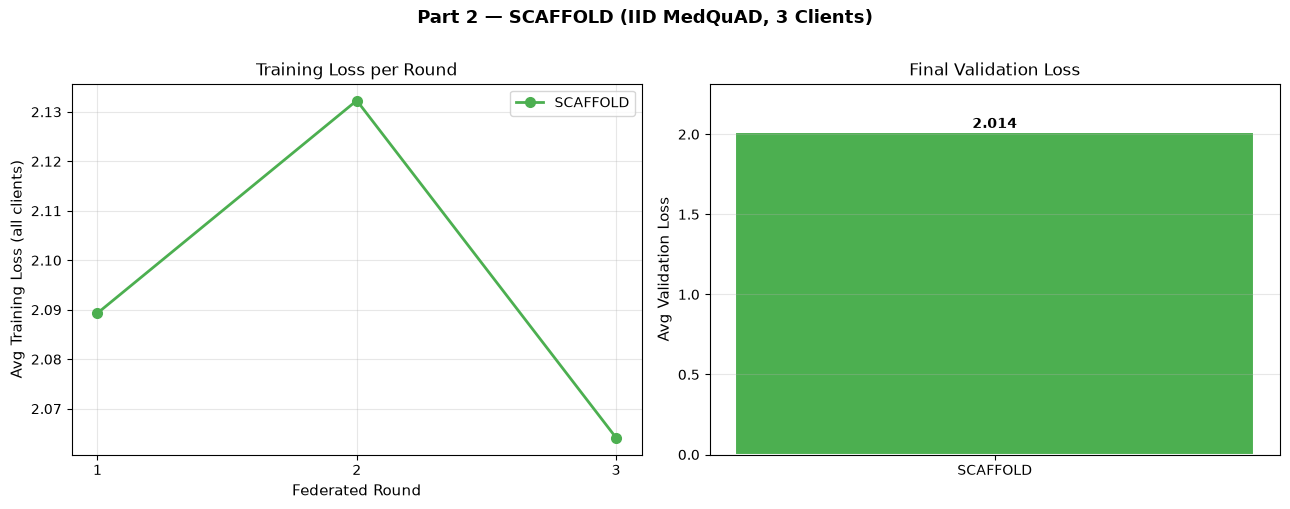

Plot saved.


In [20]:
COLORS = {"SCAFFOLD": "#4CAF50"}
MARKERS = {"SCAFFOLD": "o"}

rounds = list(range(1, CFG.total_rounds + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part 2 — SCAFFOLD (IID MedQuAD, 3 Clients)",
             fontsize=13, fontweight="bold", y=1.01)

# Training loss per round
ax = axes[0]
for algo in ALGORITHMS:
    avg_losses = [np.mean(r) for r in results[algo]]
    ax.plot(rounds, avg_losses, color=COLORS[algo], marker=MARKERS[algo],
            linewidth=2, markersize=7, label=algo)
ax.set_xlabel("Federated Round", fontsize=11)
ax.set_ylabel("Avg Training Loss (all clients)", fontsize=11)
ax.set_title("Training Loss per Round", fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Final validation loss bar chart
ax = axes[1]
avg_val_losses = [np.mean(val_results[a]) for a in ALGORITHMS]
bars = ax.bar(ALGORITHMS, avg_val_losses,
              color=[COLORS[a] for a in ALGORITHMS],
              edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, avg_val_losses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Avg Validation Loss", fontsize=11)
ax.set_title("Final Validation Loss", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(avg_val_losses) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, "part2_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")


## 12. Algorithm Notes

### SCAFFOLD
- **Best for:** Non-IID data with strong client drift; theoretically the most principled correction
- **Key idea:** Control variates estimate and cancel out the bias each client introduces
- **Weakness:** Each client must send a *control variate update* back to the server (2× communication); requires stateful clients
- **Cost:** 2× uplink communication; stateful clients (c_i persists between rounds)

### FedAdam
- **Best for:** When FedAvg converges slowly; server has compute resources
- **Key idea:** Adam's adaptive learning rate per parameter accelerates server-side convergence
- **Tune:** `CFG.fedadam_server_lr` (typically 0.001–0.1); betas as in standard Adam
- **Cost:** Stateful server (stores m, v for all LoRA parameters); same communication as FedAvg

---
**Next step:** Open `federated_part3_comparison.ipynb` to see the full 4-algorithm comparison.
